#Anomaly Detection Model
##AI-Powered SOC Project — CICIDS2017
This notebook builds an Isolation Forest anomaly detection model trained only on BENIGN traffic.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import gc
import warnings
warnings.filterwarnings('ignore')

print(" All libraries loaded!")

 All libraries loaded!


In [4]:
print("Loading CICIDS2017 dataset...")

df = pd.read_parquet("../data/processed/cicids2017.parquet")

print(f" Loaded! {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nAttack type counts:")
print(df["Label"].value_counts())

Loading CICIDS2017 dataset...
 Loaded! 2,827,876 rows, 81 columns

Attack type counts:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [5]:
memory_mb = df.memory_usage(deep=True).sum() / 1024 / 1024
print(f"Dataset using {memory_mb:.0f} MB of your RAM")
print(f"That is {memory_mb/1024:.1f} GB out of your 8GB")

if memory_mb > 3000:
    print("  Large - we will sample carefully")
else:
    print(" Memory looks fine")

Dataset using 2235 MB of your RAM
That is 2.2 GB out of your 8GB
 Memory looks fine


In [6]:
print("Separating BENIGN from attack traffic...")

df_benign = df[df["Label"] == "BENIGN"].copy()
df_attacks = df[df["Label"] != "BENIGN"].copy()

print(f"Benign rows:  {len(df_benign):,}")
print(f"Attack rows:  {len(df_attacks):,}")
print(f"\nBenign = {len(df_benign)/len(df)*100:.1f}% of dataset")
print(f"Attacks = {len(df_attacks)/len(df)*100:.1f}% of dataset")

Separating BENIGN from attack traffic...
Benign rows:  2,271,320
Attack rows:  556,556

Benign = 80.3% of dataset
Attacks = 19.7% of dataset


In [7]:
SAMPLE_SIZE = 150000

print(f"Taking a sample of {SAMPLE_SIZE:,} benign rows...")

df_benign_sample = df_benign.sample(
    n=SAMPLE_SIZE,
    random_state=42
)

print(f" Sample created: {df_benign_sample.shape}")


del df_benign
del df_attacks
del df
gc.collect()

print("Memory freed up successfully!")

Taking a sample of 150,000 benign rows...
 Sample created: (150000, 81)
Memory freed up successfully!


In [8]:
print("Preparing features for training...")

columns_to_drop = [
    col for col in ["Label", "dataset", "source_file"] 
    if col in df_benign_sample.columns
]

print(f"Dropping these non-numeric columns: {columns_to_drop}")

X_train = df_benign_sample.drop(columns=columns_to_drop)


non_numeric = X_train.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Also dropping non-numeric columns: {non_numeric}")
    X_train = X_train.drop(columns=non_numeric)

print(f" Training features ready: {X_train.shape}")
print(f"Model will learn from {X_train.shape[1]} features")

Preparing features for training...
Dropping these non-numeric columns: ['Label', 'dataset', 'source_file']
 Training features ready: (150000, 78)
Model will learn from 78 features


In [9]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest model...")

iso_forest = IsolationForest(
    n_estimators=100,      
    contamination=0.05,    
    random_state=42,       
    n_jobs=-1             
)

iso_forest.fit(X_train)

print(" Model trained successfully!")

Training Isolation Forest model...
 Model trained successfully!


In [10]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/isolation_forest.pkl"
joblib.dump(iso_forest, model_path)

print(f"Model saved to: {model_path}")


Model saved to: ../models/isolation_forest.pkl


In [11]:
print("Reloading dataset for evaluation...")

df_full = pd.read_parquet("../data/processed/cicids2017.parquet")


df_benign_eval = df_full[df_full["Label"] == "BENIGN"].sample(
    n=25000, random_state=42
)
df_attack_eval = df_full[df_full["Label"] != "BENIGN"].sample(
    n=25000, random_state=42
)

df_eval = pd.concat([df_benign_eval, df_attack_eval]).sample(
    frac=1, random_state=42
).reset_index(drop=True)

print(f" Evaluation set ready: {df_eval.shape}")
print(f"Benign rows: {len(df_benign_eval):,}")
print(f"Attack rows: {len(df_attack_eval):,}")

true_labels = df_eval["Label"].copy()

columns_to_drop = [
    col for col in ["Label", "dataset", "source_file"] 
    if col in df_eval.columns
]
X_eval = df_eval.drop(columns=columns_to_drop)

non_numeric = X_eval.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    X_eval = X_eval.drop(columns=non_numeric)


del df_full
gc.collect()

print(" Ready to make predictions!")

Reloading dataset for evaluation...
 Evaluation set ready: (50000, 81)
Benign rows: 25,000
Attack rows: 25,000
 Ready to make predictions!


In [12]:
print("Running model on evaluation data...")

predictions = iso_forest.predict(X_eval)

predictions_binary = (predictions == -1).astype(int)

results_df = pd.DataFrame({
    "true_label": true_labels.values,
    "predicted_anomaly": predictions_binary
})

print(" Predictions complete!")
print(f"\nTotal rows tested: {len(results_df):,}")
print(f"Flagged as anomalous: {predictions_binary.sum():,} ({predictions_binary.mean()*100:.1f}%)")
print(f"Flagged as normal:    {(predictions_binary==0).sum():,} ({(predictions_binary==0).mean()*100:.1f}%)")

Running model on evaluation data...
 Predictions complete!

Total rows tested: 50,000
Flagged as anomalous: 8,942 (17.9%)
Flagged as normal:    41,058 (82.1%)


In [13]:
print("Detection rate by attack type:")
print("="*55)

detection_summary = results_df.groupby("true_label")["predicted_anomaly"].agg(
    Total="count",
    Flagged="sum"
)

detection_summary["Detection_Rate_%"] = (
    detection_summary["Flagged"] / detection_summary["Total"] * 100
).round(1)

print(detection_summary.sort_values("Detection_Rate_%", ascending=False))

Detection rate by attack type:
                          Total  Flagged  Detection_Rate_%
true_label                                                
Heartbleed                    1        1             100.0
Infiltration                  1        1             100.0
DoS Hulk                  10358     6397              61.8
DoS slowloris               249      144              57.8
DoS Slowhttptest            263       68              25.9
DDoS                       5727     1032              18.0
DoS GoldenEye               414       40               9.7
BENIGN                    25000     1255               5.0
Web Attack � XSS             33        1               3.0
Bot                          87        0               0.0
FTP-Patator                 345        0               0.0
PortScan                   7200        3               0.0
SSH-Patator                 266        0               0.0
Web Attack � Brute Force     56        0               0.0


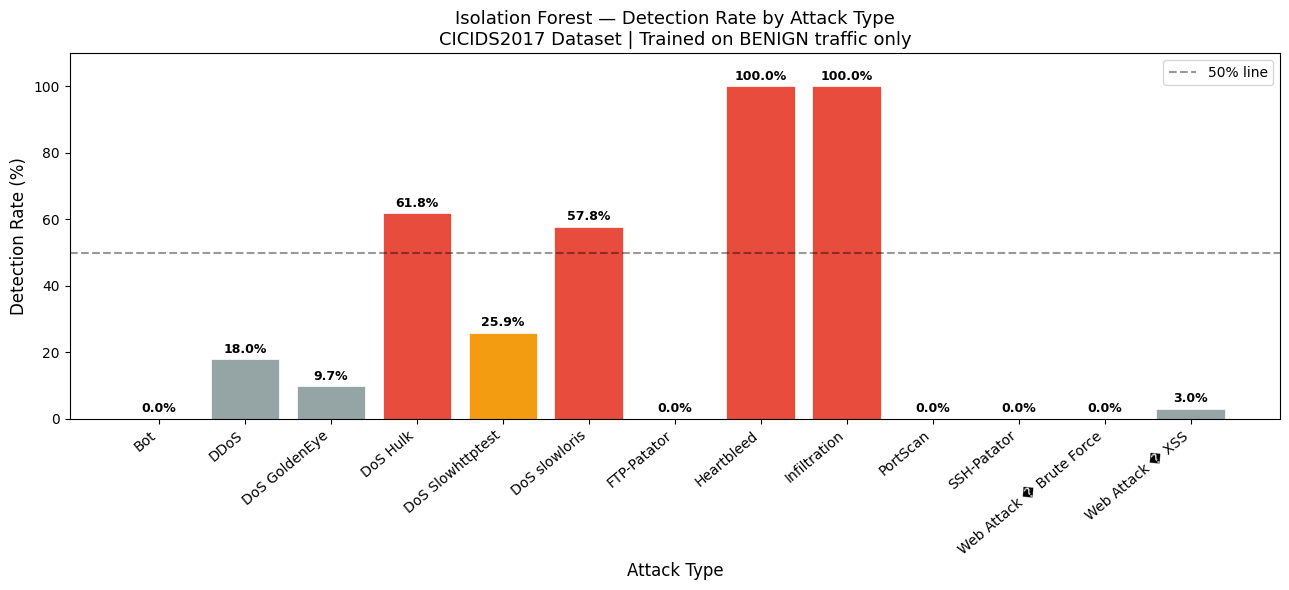

 Chart saved to reports/figures/


In [14]:
#Filtering out BENIGN from the chart, only want to show attack detection rates
attack_summary = detection_summary[detection_summary.index != "BENIGN"].copy()

plt.figure(figsize=(13, 6))

colors = [
    "#e74c3c" if x > 50 
    else "#f39c12" if x > 25 
    else "#95a5a6" 
    for x in attack_summary["Detection_Rate_%"]
]

bars = plt.bar(
    range(len(attack_summary)),
    attack_summary["Detection_Rate_%"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

#Adding value labels on top of each bar
for i, (bar, val) in enumerate(zip(bars, attack_summary["Detection_Rate_%"])):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{val}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.xlabel("Attack Type", fontsize=12)
plt.ylabel("Detection Rate (%)", fontsize=12)
plt.title(
    "Isolation Forest — Detection Rate by Attack Type\n"
    "CICIDS2017 Dataset | Trained on BENIGN traffic only",
    fontsize=13
)
plt.xticks(range(len(attack_summary)), attack_summary.index, rotation=40, ha="right")
plt.ylim(0, 110)
plt.axhline(y=50, color="black", linestyle="--", alpha=0.4, label="50% line")
plt.legend(fontsize=10)
plt.tight_layout()

os.makedirs("../reports/figures", exist_ok=True)
plt.savefig(
    "../reports/figures/anomaly_detection_results.png", 
    dpi=150, 
    bbox_inches="tight"
)
plt.show()
print(" Chart saved to reports/figures/")

In [15]:
benign_results = results_df[results_df["true_label"] == "BENIGN"]
fp_rate = benign_results["predicted_anomaly"].mean() * 100

print("="*50)
print("FALSE POSITIVE ANALYSIS")
print("="*50)
print(f"BENIGN flows tested:          {len(benign_results):,}")
print(f"Incorrectly flagged:          {benign_results['predicted_anomaly'].sum():,}")
print(f"False Positive Rate:          {fp_rate:.1f}%")

print()
if fp_rate < 10:
    print(" Low false positive rate - analysts won't be overwhelmed")
elif fp_rate < 20:
    print("  Moderate - some tuning may help")
else:
    print(" High - consider lowering contamination parameter")

FALSE POSITIVE ANALYSIS
BENIGN flows tested:          25,000
Incorrectly flagged:          1,255
False Positive Rate:          5.0%

 Low false positive rate - analysts won't be overwhelmed


In [16]:
attack_results = results_df[results_df["true_label"] != "BENIGN"]
overall_detection = attack_results["predicted_anomaly"].mean() * 100

print("="*60)
print("   ANOMALY DETECTION MODEL — COMPLETE SUMMARY")
print("="*60)
print(f"  Model:                Isolation Forest")
print(f"  Dataset:              CICIDS2017")
print(f"  Training data:        BENIGN only ({SAMPLE_SIZE:,} samples)")
print(f"  Evaluation set:       50,000 flows (50% benign, 50% attack)")
print()
print(f"  Overall Detection Rate:   {overall_detection:.1f}%")
print(f"  False Positive Rate:      {fp_rate:.1f}%")
print()
print(f"  Model saved:    ../models/isolation_forest.pkl")
print(f"  Chart saved:    ../reports/figures/anomaly_detection_results.png")
print("="*60)
print(" Anomaly detection notebook has been completed!!")


   ANOMALY DETECTION MODEL — COMPLETE SUMMARY
  Model:                Isolation Forest
  Dataset:              CICIDS2017
  Training data:        BENIGN only (150,000 samples)
  Evaluation set:       50,000 flows (50% benign, 50% attack)

  Overall Detection Rate:   30.7%
  False Positive Rate:      5.0%

  Model saved:    ../models/isolation_forest.pkl
  Chart saved:    ../reports/figures/anomaly_detection_results.png
 Anomaly detection notebook has been completed!!
